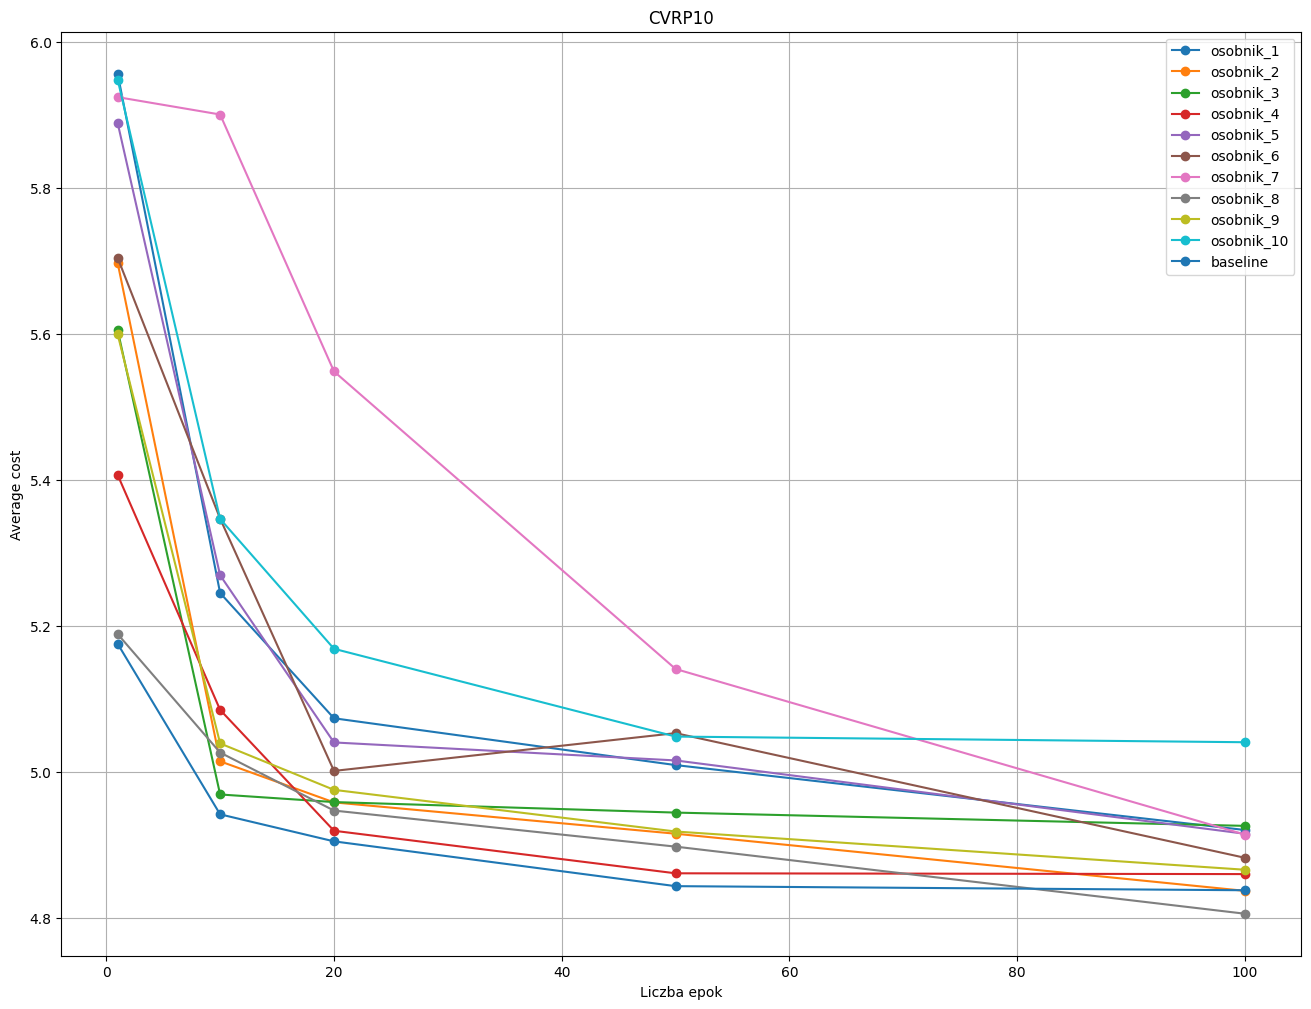

<Figure size 640x480 with 0 Axes>

In [11]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# Wczytanie CSV
df = pd.read_csv("metrics/scoreToEpochs.csv")

# Oddzielamy kolumnę epok
epochs = df["epochs"]
plt.figure(figsize=(16, 12))  # szeroki wykres

# Rysowanie każdej kolumny osobnika
for col in df.columns[1:]:  # pomijamy "epochs"
    plt.plot(epochs, df[col], marker='o', label=col)

plt.xlabel("Liczba epok")
plt.ylabel("Average cost")
plt.title("CVRP10")
plt.legend()
plt.grid(True)

plt.savefig("wyniki_osobnikow.png", dpi=300, bbox_inches='tight')
plt.show()
plt.savefig("wykres.png", dpi=300) 

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytaj CSV
df = pd.read_csv("/home/piotr/repos/magisterka/vrp10_20_epochs_epoch_128000.csv")

# 2. Zamień 'tensor(...)' na float
df['score'] = df['score'].str.replace('tensor\(|\)', '', regex=True).astype(float)
df["epoch"] = df["epoch"].astype(int)


# # 3. Rysowanie wykresu
# plt.figure(figsize=(16, 12)) 
# plt.title("VRP20, target settings, osobnik 1")
# plt.xlabel("Epoch")
# plt.ylabel("Score")

# for osobnik_id, group in df.groupby("osobnik"):
#     if osobnik_id == 0:
#         plt.plot(group["epoch"], group["score"],marker='o',  alpha=1, label=f"BASELINE")
#     else:
#         plt.plot(group["epoch"], group["score"], marker='o', alpha=0.7, label=f"Osobnik {osobnik_id}")

# plt.legend()
# plt.grid(True)
# plt.savefig("vrp20_osobnik1.png", dpi=300) 
# plt.show()

epochs_of_interest = [0, 5, 19]

# for osobnik_id, group in df.groupby("osobnik"):
#     print(f"\nOsobnik {osobnik_id}:")
    
#     for ep in epochs_of_interest:
#         val = group[group["epoch"] == ep]["score"]
#         if not val.empty:
#             print(f"  Epoch {ep}: {val.values[0]}")
#         else:
#             print(f"  Epoch {ep}: brak danych")
# # Ranking na podstawie epoki 20
epoch_20 = df[df["epoch"] == 19].copy()

# # sortowanie (zakładam: niższy score = lepszy; jeśli odwrotnie → ascending=False)
epoch_20 = epoch_20.sort_values(by="score", ascending=True).reset_index(drop=True)

# print("\n=== Ranking (epoka 20) ===")

prev_score = None
best_score = epoch_20.loc[0, "score"]
for i, row in epoch_20.iterrows():
    osobnik = row["osobnik"]
    score = row["score"]
    
    if i == 0:
        diff_pct = 0.0
    else:
        # procentowa strata względem poprzedniego
        diff_pct = ((score - best_score) / best_score) * 100 if prev_score != 0 else 0.0
    
    print(f"{i+1}. Osobnik {osobnik}: {score:.4f} (strata: {diff_pct:.2f}%)")
    
    prev_score = score

1. Osobnik 0.0: 4.8059 (strata: 0.00%)
2. Osobnik 4.0: 4.8302 (strata: 0.51%)
3. Osobnik 2.0: 4.8324 (strata: 0.55%)
4. Osobnik 9.0: 4.8337 (strata: 0.58%)
5. Osobnik 1.0: 4.8434 (strata: 0.78%)
6. Osobnik 8.0: 4.8450 (strata: 0.81%)
7. Osobnik 3.0: 4.8451 (strata: 0.82%)
8. Osobnik 7.0: 4.8517 (strata: 0.95%)
9. Osobnik 6.0: 4.8692 (strata: 1.32%)
10. Osobnik 5.0: 4.8949 (strata: 1.85%)
11. Osobnik 10.0: 4.9662 (strata: 3.34%)


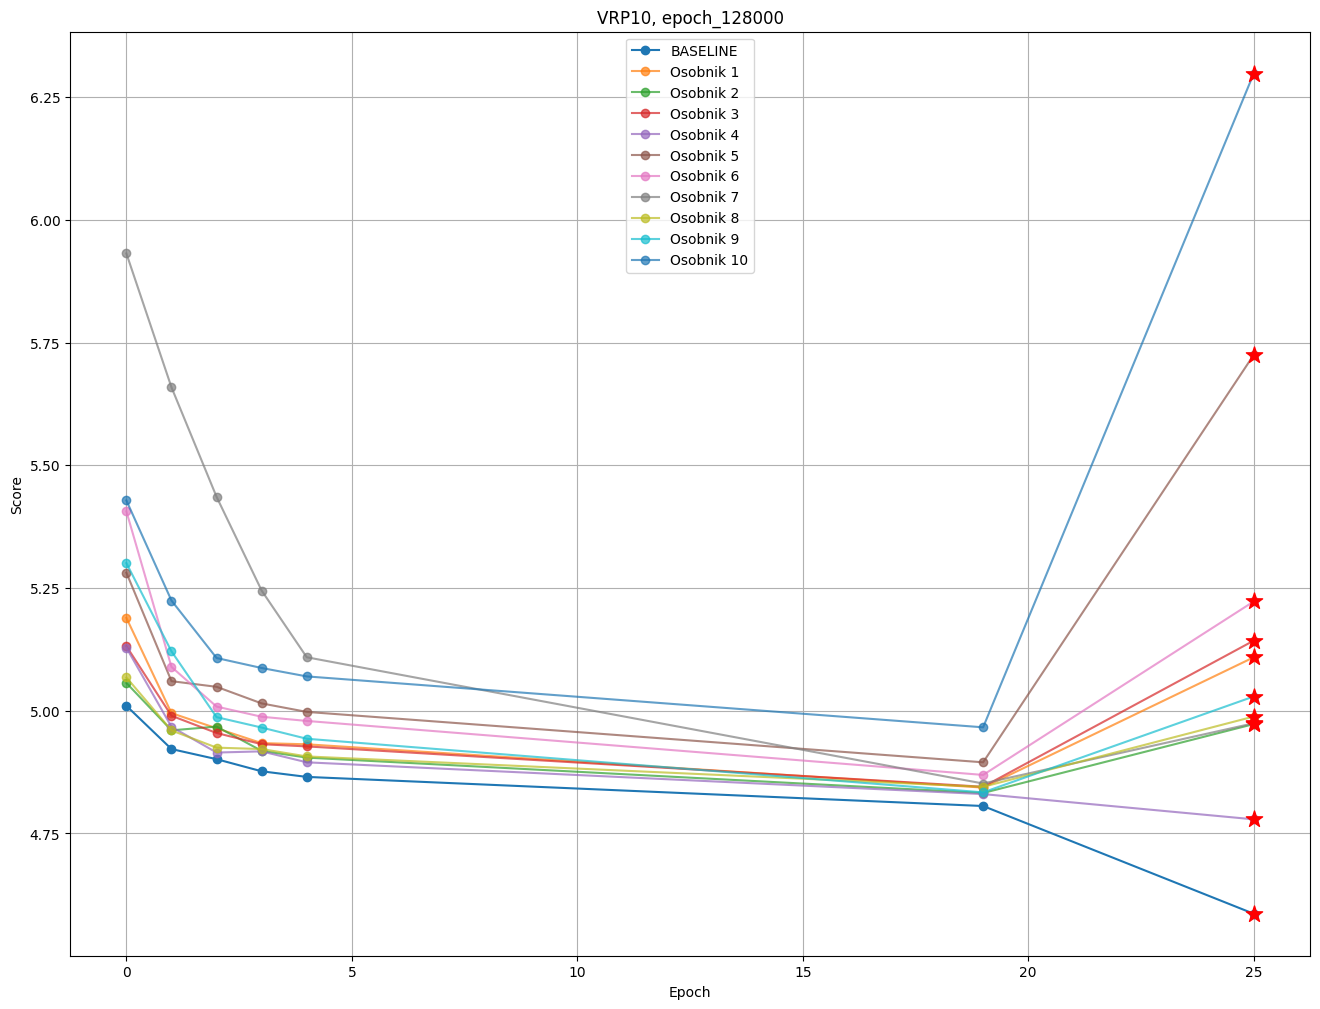

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytaj CSV
df = pd.read_csv("/home/piotr/repos/magisterka/vrp10_20_epochs_epoch_128000.csv")

# 2. Zamień 'tensor(...)' na float
df['score'] = df['score'].str.replace('tensor\(|\)', '', regex=True).astype(float)
df["epoch"] = df["epoch"].astype(int)

# 3. Filtr epok
last_epoch = df["epoch"].max()
epochs_of_interest = [0,1,2,3,4, last_epoch]
df_filtered = df[df["epoch"].isin(epochs_of_interest)]

# 4. Rysowanie wykresu
plt.figure(figsize=(16, 12))
plt.title("VRP10, epoch_128000")
plt.xlabel("Epoch")
plt.ylabel("Score")

for osobnik_id, group in df_filtered.groupby("osobnik"):
    group = group.sort_values("epoch")  # aby linia była w kolejności epok
    score_0 = group[group["epoch"] == 0]["score"].values[0]
    score_4 = group[group["epoch"] == 4]["score"].values[0]
    slope = (score_4 - score_0) / 4
    custom_score = 10*(1 * score_4 - 5* slope**2) - 44

    group = pd.concat([
        group,
        pd.DataFrame({
            "epoch": [25],
            "score": [custom_score],
            "osobnik": [osobnik_id]
        })
    ])

    if osobnik_id == 0:
        plt.plot(group["epoch"], group["score"], marker='o', alpha=1, label="BASELINE")
    else:
        plt.plot(group["epoch"], group["score"], marker='o', alpha=0.7, label=f"Osobnik {osobnik_id}")
    plt.scatter(
        [25],
        [custom_score],
        marker='*',      # gwiazdka
        s=150,           # rozmiar
        color='red',
        zorder=5         # żeby było na wierzchu
    )
plt.legend()
plt.grid(True)
plt.savefig("PROBA SLOPOWANIEa.png", dpi=300)
plt.show()

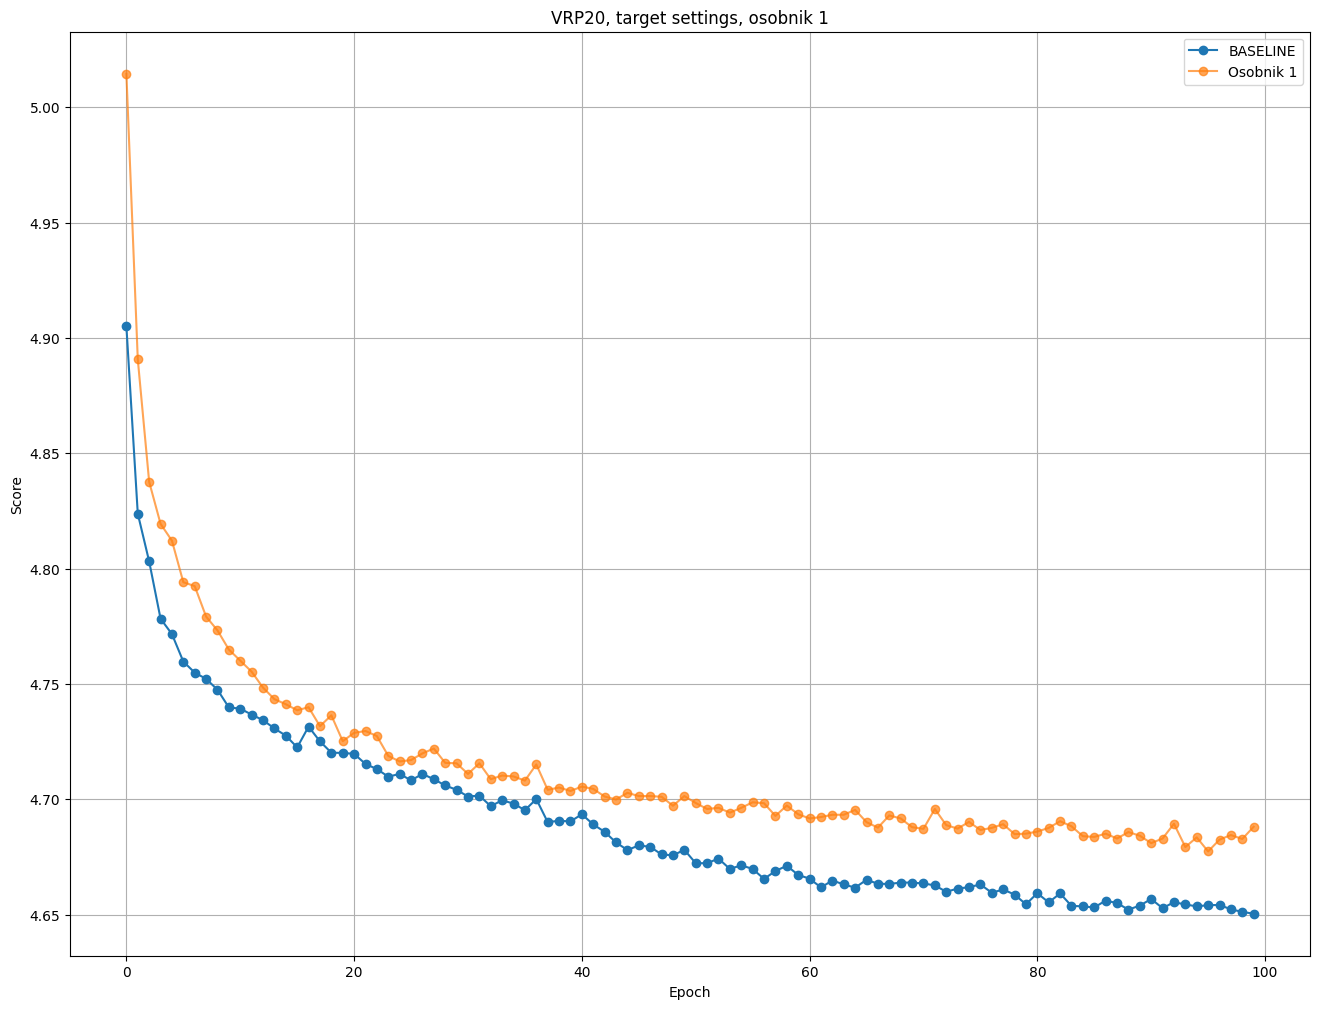

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Wczytaj CSV
df = pd.read_csv("/home/piotr/repos/magisterka/vrp10_osobnik1.csv")

# 2. Zamień 'tensor(...)' na float
df['score'] = df['score'].str.replace('tensor\(|\)', '', regex=True).astype(float)
df["epoch"] = df["epoch"].astype(int)


df2 = pd.read_csv("/home/piotr/repos/magisterka/vrp10_baseline.csv")
df2['score'] = df2['score'].str.replace('tensor\(|\)', '', regex=True).astype(float)
df2["epoch"] = df2["epoch"].astype(int)

# 3. Rysowanie wykresu
plt.figure(figsize=(16, 12)) 
plt.title("VRP20, target settings, osobnik 1")
plt.xlabel("Epoch")
plt.ylabel("Score")
for osobnik_id, group in df2.groupby("osobnik"):
    if osobnik_id == 0:
        plt.plot(group["epoch"], group["score"],marker='o',  alpha=1, label=f"BASELINE")
    else:
        plt.plot(group["epoch"], group["score"], marker='o', alpha=0.7, label=f"Osobnik {osobnik_id}")
for osobnik_id, group in df.groupby("osobnik"):
    if osobnik_id == 0:
        plt.plot(group["epoch"], group["score"],marker='o',  alpha=1, label=f"BASELINE")
    else:
        plt.plot(group["epoch"], group["score"], marker='o', alpha=0.7, label=f"Osobnik {osobnik_id}")

plt.legend()
plt.grid(True)
plt.savefig("vrp20_osobnik1vsbaselina.png", dpi=300) 
plt.show()
